In [98]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.preprocessing import  LabelEncoder,StandardScaler,Normalizer, PowerTransformer, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier


In [99]:
from keras.models import Sequential
from keras.layers import Dense
from keras import layers
import tensorflow as tf

ModuleNotFoundError: No module named 'keras'

In [ ]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
# Read and check basic information
df.head()
df.info()
df.tail()
df.describe()
df.dtypes
df['Column Name'].unique()
df.columns
df.shape
df['Column Name'].value_counts()


In [ ]:
#Check for Null and Duplicate values
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
df.isnull().sum()*100/len(df)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [ ]:
df.duplicated().sum()

np.int64(107)


Dropping columns

    Passenger ID, Name Column as its not required for our modeling
    Cabin column has lot of NULL values therefore wont be helpful for making predictions



In [ ]:
df.drop(labels=['Column Name','xxxColumn name'],inplace=True,axis=1)


In [ ]:
print(df['age'].max())    # print command w/be apply here otherwise only 1st code result will appear.
print(df['age'].min())
print(df['age'].mean())

In [ ]:
#Fill missing values with its mean value of present values.
# embarked & embark town missing values changed with mode 
print('mean=', df['age'].mean())
print('median=', df['age'].median())  # Ist we will arrange data acending order.
print('mode=', df['embark_town'].mode())      # repeated value called mode.If two values (2,3,5,6,6,5) then mode 5,6.

mean= 29.69911764705882
median= 28.0
mode= 0    Southampton
Name: embark_town, dtype: object


In [ ]:
#we drop column deck and to update code df3 = df3.drop(columns=['deck']) means code store in df3.
df = df.drop(columns=['deck'])  
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [ ]:
print('mean=', df['age'].mean())
print('median=', df['age'].median())  # Ist we will arrange data acending order.
print('mode=', df['embark_town'].mode())      # repeated value called mode.If two values (2,3,5,6,6,5) then mode 5,6.

mean= 29.69911764705882
median= 28.0
mode= 0    Southampton
Name: embark_town, dtype: object


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [ ]:
df.shape

(891, 14)

# Starts data Wrangling 
## Outliers Removal

<Axes: xlabel='sex', ylabel='age'>

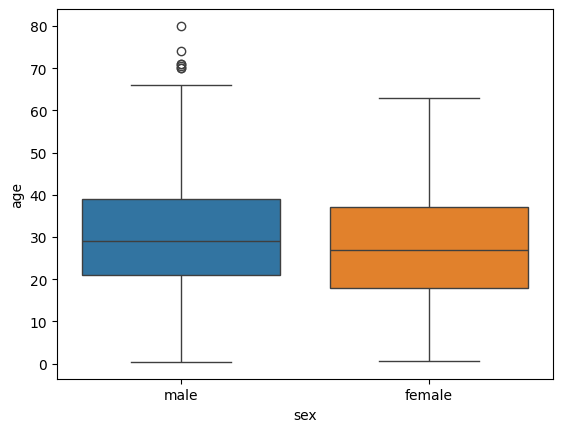

In [ ]:
import seaborn as sns
sns.boxplot(data=df, y='age', x='sex', hue='sex')

Finding & droping duplicates

In [ ]:
# Finding duplicates
df.duplicated().sum()

np.int64(111)

In [ ]:
# To check where are duplicate  where show true it means duplicate 
df_duplicates = df[df.duplicated()]
df_duplicates.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
# dropping/removeing duplicates
df.drop_duplicates(inplace=True)
df.shape    # anwser (615,14 is ok )vedio timing 1.00.36


(780, 14)

## IQR (Interquarlite range ) Method

In [ ]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
IQR
# Define the lower and upper bounds for age
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter the DataFrame to exclude outliers
df = df[(df['age'] > lower_bound) & (df['age'] < upper_bound)]

In [ ]:
df.shape  

(669, 14)

In [ ]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
IQR
# Define the lower and upper bounds for age
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter the DataFrame to exclude outliers
df2 = df[(df['fare'] > lower_bound) & (df['fare'] < upper_bound)]

In [ ]:
df.shape  

(669, 14)

<Axes: xlabel='age', ylabel='Count'>

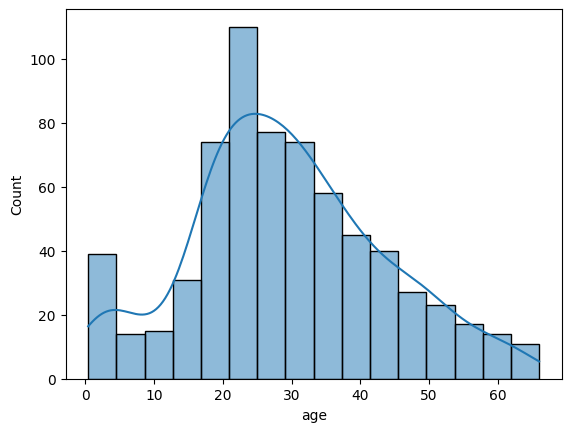

In [ ]:
sns.histplot(df['age'], kde=1)  # After data cleaning its become del shape.

# Data Normalization

In [ ]:
# Install scikit-learn using for machine learning
# !pip install scikit-learn
#min-max normalization
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#Steps for min-max normalization  time: 1:06
# 1. library imports
import pandas as pd
#2. data
df
#3. Select columns to normolize 
cols_to_normalize = ['age', 'fare']
#4. create the scaler function/tool
scaler = MinMaxScaler()
#5. fit the transform the data on scaler 
df[cols_to_normalize] =scaler.fit_transform(df[cols_to_normalize])
#6. check the data
df



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,0.329064,1,0,0.014151,S,Third,man,True,Southampton,no,False
1,1,1,female,0.573041,1,0,0.139136,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,0.390058,0,0,0.015469,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.527295,1,0,0.103644,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.527295,0,0,0.015713,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,0.420555,0,0,0.020495,S,Second,man,True,Southampton,no,True
885,0,3,female,0.588289,0,5,0.056848,Q,Third,woman,False,Queenstown,no,False
887,1,1,female,0.283318,0,0,0.058556,S,First,woman,False,Southampton,yes,True
889,1,1,male,0.390058,0,0,0.058556,C,First,man,True,Cherbourg,yes,True


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000
mean,0.421525,2.227205,0.441409,0.539611,0.457399,0.070094
std,0.494173,0.845439,0.215580,0.949472,0.873800,0.105999
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.298567,0.000000,0.000000,0.015713
50%,0.000000,2.000000,0.420555,0.000000,0.000000,0.031425
75%,1.000000,3.000000,0.573041,1.000000,1.000000,0.069291
max,1.000000,3.000000,1.000000,5.000000,6.000000,1.000000


# Organizing  data

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [ ]:
# merging and creating/renaming new column.  
df['family_size'] = df['sibsp'] + df['parch']

In [ ]:
df.columns    

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'family_size'],
      dtype='object')

<Axes: xlabel='family_size', ylabel='Count'>

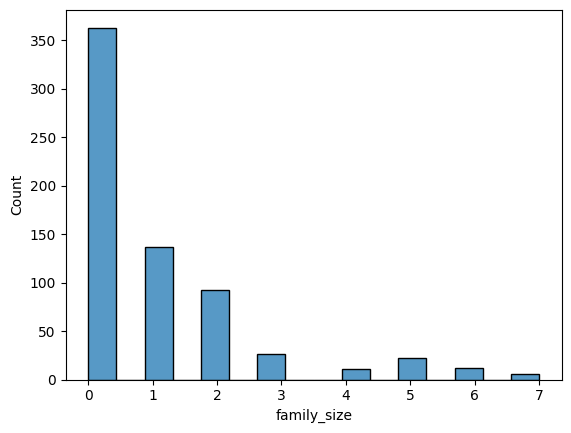

In [ ]:
sns.histplot(df['family_size'])   

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,0.329064,1,0,0.014151,S,Third,man,True,Southampton,no,False,1
1,1,1,female,0.573041,1,0,0.139136,C,First,woman,False,Cherbourg,yes,False,1
2,1,3,female,0.390058,0,0,0.015469,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,0.527295,1,0,0.103644,S,First,woman,False,Southampton,yes,False,1
4,0,3,male,0.527295,0,0,0.015713,S,Third,man,True,Southampton,no,True,0


In [ ]:
df = df.rename(columns={'survived': "survival"})  # {} used for making dictionery  1:39  time  RUN
df.columns


Index(['survival', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'family_size'],
      dtype='object')

In [ ]:
# Pivot table creation  time= 1:39  RUN
table = pd.pivot_table(df, values='fare', index='pclass', columns='survival', aggfunc=np.sum)
print(table)


survival         0          1
pclass                       
1         8.059458  23.326311
2         3.333688   3.482396
3         6.617758   2.073065


<Axes: xlabel='fare', ylabel='age'>

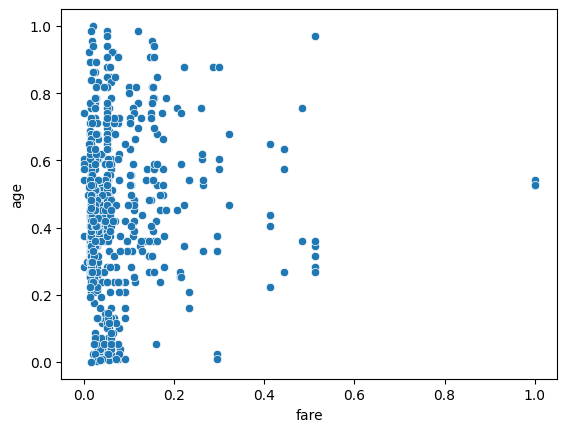

In [ ]:
# to check the relation make a plot
sns.scatterplot(data=df, x='fare', y='age')

In [ ]:
df.head()

,survival,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,0.329064,1,0,0.014151,S,Third,man,True,Southampton,no,False,1
1,1,1,female,0.573041,1,0,0.139136,C,First,woman,False,Cherbourg,yes,False,1
2,1,3,female,0.390058,0,0,0.015469,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,0.527295,1,0,0.103644,S,First,woman,False,Southampton,yes,False,1
4,0,3,male,0.527295,0,0,0.015713,S,Third,man,True,Southampton,no,True,0


In [ ]:
#Now we run minmax scalar which we stop in data normalization.lets apply here.

#Steps for min-max normalization  time: 1:06
# 1. library imports
import pandas as pd
#2. data
df
#3. Select columns to normolize 
cols_to_normalize = ['age', 'fare']
#4. create the scaler function/tool
scaler = MinMaxScaler()
#5. fit the transform the data on scaler 
df[cols_to_normalize] =scaler.fit_transform(df[cols_to_normalize])
#6. check the data
df

,survival,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,0.329064,1,0,0.014151,S,Third,man,True,Southampton,no,False,1
1,1,1,female,0.573041,1,0,0.139136,C,First,woman,False,Cherbourg,yes,False,1
2,1,3,female,0.390058,0,0,0.015469,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,0.527295,1,0,0.103644,S,First,woman,False,Southampton,yes,False,1
4,0,3,male,0.527295,0,0,0.015713,S,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,0.420555,0,0,0.020495,S,Second,man,True,Southampton,no,True,0
885,0,3,female,0.588289,0,5,0.056848,Q,Third,woman,False,Queenstown,no,False,5
887,1,1,female,0.283318,0,0,0.058556,S,First,woman,False,Southampton,yes,True,0
889,1,1,male,0.390058,0,0,0.058556,C,First,man,True,Cherbourg,yes,True,0


In [ ]:
df.to_csv('preprocessed_data.csv')   # note saving in csv format will take short space 

<Axes: xlabel='family_size', ylabel='age'>

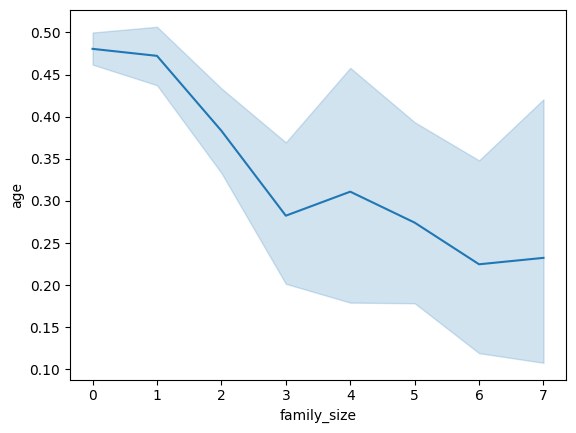

In [ ]:
sns.lineplot(data=df, x='family_size', y='age')

Prediction

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['sex'].value_counts()

sex
male      414
female    255
Name: count, dtype: int64

In [ ]:
df['sex'] = le.fit_transform(df["sex"])

In [ ]:
# Let's separate input and output columns for prediction
x = df[['pclass', 'sex', 'age']]
y = df['survival']

In [ ]:
# lets check the value counts in y [0:Dead,1:Survived]
y.value_counts()

survival
0    387
1    282
Name: count, dtype: int64

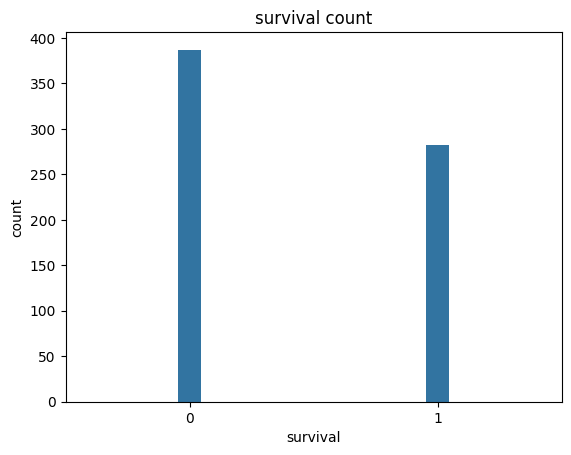

In [ ]:
plt.title('survival count')
sns.countplot(x = y,width = 0.09);

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Assume you have your data in variables 'X' and 'y'
model = LogisticRegression()
model.fit(x, y)  # Train the model

# Make predictions
y_pred = model.predict(x)

# Create a new DataFrame
df = pd.DataFrame({"survival": y, "survival Prediction": y_pred})
df.head(5)

,survival,survival Prediction
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0



Prediction¶

    in this section, prediction task using DecisionTreeClassifier

1. Required steps before buliding model

    separated input and output columns for prediction

    checking the value counts in y where [0:Dead,1:Survived]

2.Building model

    Building the model on DecisionTreeClassifier.Our model predict weather passengers will survived or not on columns like 'Pclass', 'Sex', 'Age'

Model Evaluation

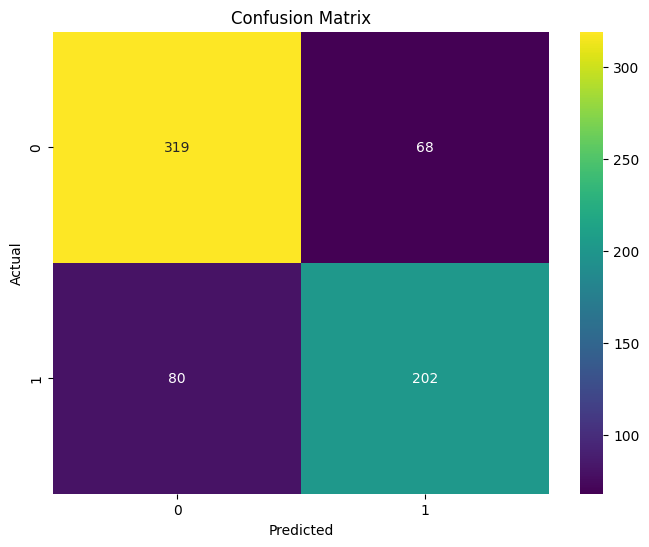

In [ ]:
# confusion matrix
from sklearn.metrics import  confusion_matrix
cm = confusion_matrix(y, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='viridis', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
#ConfusionMatrixDisplay.from_predictions(y, y_pred);

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       387
           1       0.75      0.72      0.73       282

    accuracy                           0.78       669
   macro avg       0.77      0.77      0.77       669
weighted avg       0.78      0.78      0.78       669



In [ ]:
# overall accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.7787742899850523


Model Evaluation¶

    assessing the performance of a trained machine learning model on unseen data. It involves using various metrics and techniques to understand how well the model generalizes to new data

1. Plot the confusion matrix

    confusion matrix summarizes the performance of a classification model. It consists of four main components:True Positive, True Negative, False Positive, False Negative

2. getting classification Report

    precision, recall, f1-score, support

3. getting overall accuracy

    Shows how accuracy of model that we build

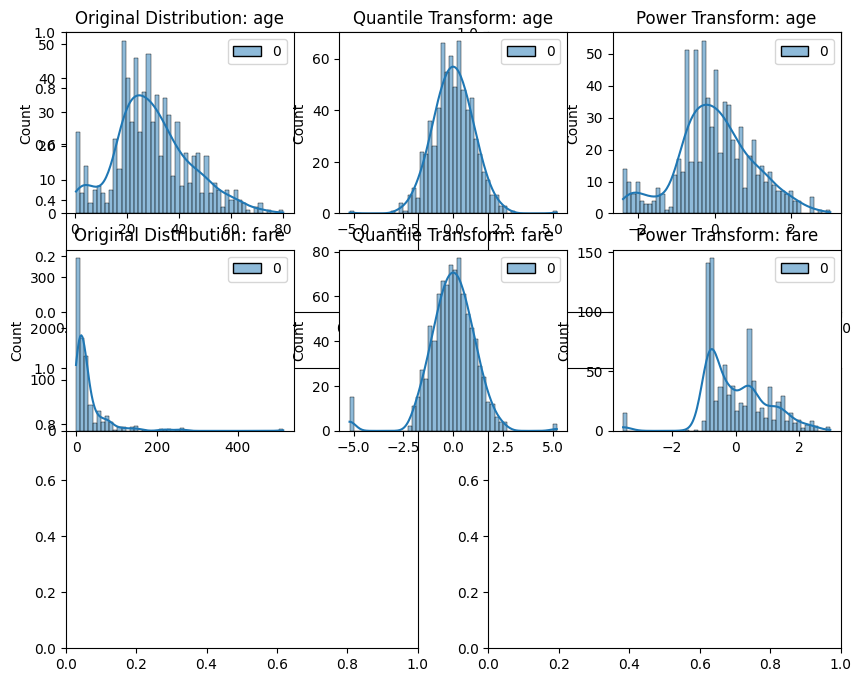

In [112]:
numeric_cols = ['age', 'fare']
df2 = sns.load_dataset("titanic")
pt = PowerTransformer()
qt = QuantileTransformer(n_quantiles=500, output_distribution='normal')
numeric_cols = ['age', 'fare']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
j = 1
for col in numeric_cols:
    data = np.array(df2[col]).reshape(-1, 1)
    y = pt.fit_transform(data)
    x = qt.fit_transform(data)
    plt.subplot(3, 3, j)
    sns.histplot(data, bins=50, kde=True)
    plt.title(f"Original Distribution: {col}")
    plt.subplot(3, 3, j+1)
    sns.histplot(x, bins=50, kde=True)
    plt.title(f"Quantile Transform: {col}")
    plt.subplot(3, 3, j+2)
    sns.histplot(y, bins=50, kde=True)
    plt.title(f"Power Transform: {col}")
    j += 3
fig.show()

In [ ]:
sns.heatmap(df[['pclass', 'age']].corr(), annot=True);

In [ ]:
sns.histplot(df['age'], kde=True)

In [ ]:
df_sex = df[['Survived','Sex']].groupby(['Survived','Sex']).agg({'Sex':'count'})
df_sex = df_sex.rename(columns={'Sex':'count'}).reset_index()
df_sex

In [ ]:
fig = px.bar(df_sex,x='Sex',y='count',color='Survived',color_continuous_scale=color_scales[3])
fig.update_layout(height=400,width=600,title='Survival based on Gender')

In [ ]:
def grp_age(x):
    if x < 5:
        grp = 'Toddler'
    elif x >= 5 and x < 12:
        grp = 'Child'
    elif x >= 12 and x < 18:
        grp = 'Youth'
    else:
        grp = 'Adult'
    return grp

df['Age_Category'] = df['Age'].apply(grp_age)

In [ ]:
fig = px.bar(df_age, x='Age_Category', y='count', color='Survived', color_continuous_scale=color_scales[0])
fig.update_layout(height=400,width=700,title='Survival based on Age Category')

In [ ]:
#Mulivariate Analysis
encoder = LabelEncoder()
for col in ['Sex','Embarked']:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
corr_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',  'Fare','Embarked'] 
sns.heatmap(data=df[corr_cols].corr(),annot=True,cmap='Blues')

In [ ]:
#Pair Plot
sns.pairplot(df,corner=True)

In [ ]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['Red', 'green'],shadow = True);

In [ ]:
sns.histplot(df, x='Age', hue='Sex', multiple='stack', palette='pastel', kde=True)

In [ ]:
g = sns.PairGrid(df[['Age', 'Fare', 'Pclass', 'Survived']]);
g.map_upper(sns.scatterplot)
g.map_diag(sns.histplot)
g.map_lower(sns.kdeplot)